# 01 — Exploración de MNIST como grafo de píxeles

Objetivo: documentar fuente, dimensiones, balance de clases, intensidades y estructura espacial antes de modelar.

In [1]:
from pathlib import Path
import sys, urllib.request
import numpy as np

SEED = 2026
rng = np.random.default_rng(SEED)

# Funciona desde notebooks/ en el repositorio y también en Colab.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw" / "mnist.npz"
SRC = ROOT / "src"
if not SRC.exists():
    # Si se subió solo el notebook, crea una ruta local y descarga los datos.
    ROOT = Path.cwd()
    DATA = ROOT / "mnist.npz"
if not DATA.exists():
    DATA.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", DATA
    )
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

data = np.load(DATA)
x_train = data["x_train"].astype(np.float32) / 255.0
y_train = data["y_train"].astype(np.int64)
x_test = data["x_test"].astype(np.float32) / 255.0
y_test = data["y_test"].astype(np.int64)
print("Semilla:", SEED, "| entrenamiento:", x_train.shape, "| prueba:", x_test.shape)

Semilla: 2026 | entrenamiento: (60000, 28, 28) | prueba: (10000, 28, 28)


## Diccionario de variables

| Variable | Tipo | Unidad | Descripción |
|---|---|---|---|
| `x_train`, `x_test` | uint8 → float32 | intensidad [0,1] | Imágenes 28×28 |
| `y_train`, `y_test` | entero | clase 0–9 | Dígito real |

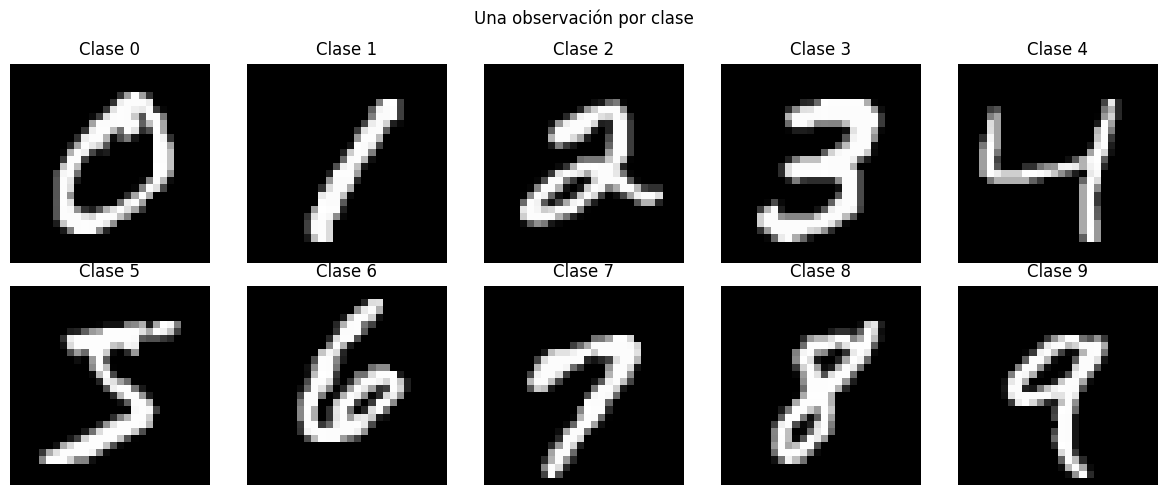

In [2]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for k, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == k)[0]
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(f"Clase {k}")
    ax.axis("off")
plt.suptitle("Una observación por clase")
plt.tight_layout(); plt.show()

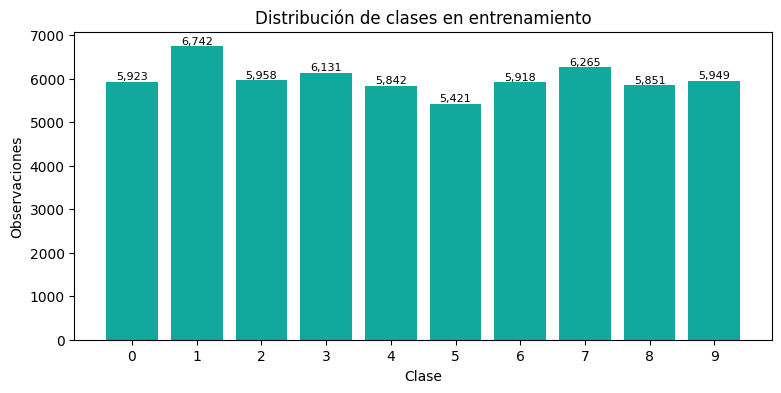

Razón mayor/menor: 1.243681977494927


In [3]:
counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(9, 4))
plt.bar(range(10), counts, color="#13A89E")
plt.xticks(range(10)); plt.xlabel("Clase"); plt.ylabel("Observaciones")
plt.title("Distribución de clases en entrenamiento")
for k, c in enumerate(counts): plt.text(k, c + 50, f"{c:,}", ha="center", fontsize=8)
plt.show()
print("Razón mayor/menor:", counts.max()/counts.min())

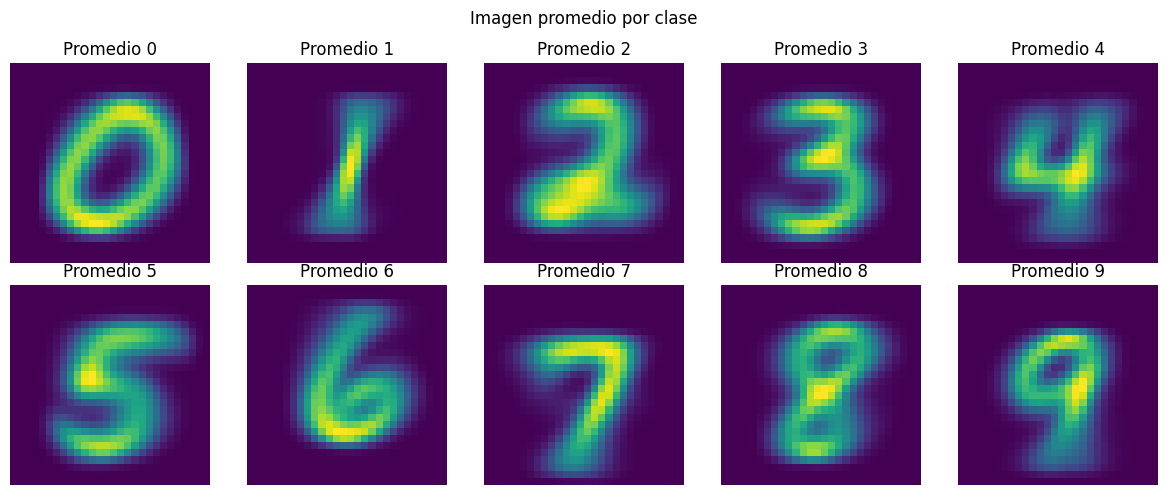

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[y_train == k].mean(axis=0), cmap="viridis")
    ax.set_title(f"Promedio {k}"); ax.axis("off")
plt.suptitle("Imagen promedio por clase")
plt.tight_layout(); plt.show()

## Lectura

Las clases son aproximadamente balanceadas (la clase mayor no duplica a la menor), por lo que se reporta exactitud junto con métricas macro. Los promedios conservan geometría local; por eso tiene sentido probar un modelo que utilice la vecindad de Moore entre píxeles.

---
# Continuación: modelos y validación

In [5]:
from pathlib import Path
import sys, urllib.request
import numpy as np

SEED = 2026
rng = np.random.default_rng(SEED)

# Funciona desde notebooks/ en el repositorio y también en Colab.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw" / "mnist.npz"
SRC = ROOT / "src"
if not SRC.exists():
    # Si se subió solo el notebook, crea una ruta local y descarga los datos.
    ROOT = Path.cwd()
    DATA = ROOT / "mnist.npz"
if not DATA.exists():
    DATA.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", DATA
    )
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

data = np.load(DATA)
x_train = data["x_train"].astype(np.float32) / 255.0
y_train = data["y_train"].astype(np.int64)
x_test = data["x_test"].astype(np.float32) / 255.0
y_test = data["y_test"].astype(np.int64)
print("Semilla:", SEED, "| entrenamiento:", x_train.shape, "| prueba:", x_test.shape)

Semilla: 2026 | entrenamiento: (60000, 28, 28) | prueba: (10000, 28, 28)


In [6]:
from modelado_mnist import (
    GraphMLP, SoftmaxRegression, graph_message_features, raw_features,
    stratified_indices, stratified_split, classification_metrics
)

raw_train, raw_test = raw_features(x_train), raw_features(x_test)
graph_train = graph_message_features(x_train, alpha=0.35, steps=2)
graph_test = graph_message_features(x_test, alpha=0.35, steps=2)
idx = stratified_indices(y_train, 30000, seed=SEED)
tr, va = stratified_split(y_train[idx], val_fraction=0.15, seed=SEED)
print(raw_train.shape, graph_train.shape)

(60000, 784) (60000, 784)


## Modelo 1 — Regresión Softmax

`P(y=k|x)=exp(w_kᵀx+b_k)/Σ_j exp(w_jᵀx+b_j)`. Es un límite inferior interpretable: separa clases mediante fronteras lineales.

In [7]:
softmax = SoftmaxRegression(784, l2=1e-4, seed=SEED)
hist_softmax = softmax.fit(raw_train[idx][tr], y_train[idx][tr], raw_train[idx][va], y_train[idx][va], epochs=12, seed=SEED)
m_softmax = classification_metrics(y_test, softmax.predict_proba(raw_test))
{k: round(v, 4) for k, v in m_softmax.items() if k != "confusion_matrix"}

{'accuracy': 0.923,
 'precision_macro': 0.9219,
 'recall_macro': 0.9222,
 'f1_macro': 0.9219,
 'log_loss': 0.2797}

## Modelo 2 — Graph-MLP

Primero propaga intensidad por el grafo de 8 vecinos durante dos pasos; después aplica una capa ReLU de 64 unidades y una salida Softmax. Combina el supuesto de localidad espacial con una frontera no lineal.

In [8]:
graph_mlp = GraphMLP(784, hidden=64, l2=1e-4, seed=SEED)
hist_graph = graph_mlp.fit(graph_train[idx][tr], y_train[idx][tr], graph_train[idx][va], y_train[idx][va], epochs=12, seed=SEED)
m_graph = classification_metrics(y_test, graph_mlp.predict_proba(graph_test))
{k: round(v, 4) for k, v in m_graph.items() if k != "confusion_matrix"}

{'accuracy': 0.9556,
 'precision_macro': 0.9552,
 'recall_macro': 0.9552,
 'f1_macro': 0.9551,
 'log_loss': 0.1519}

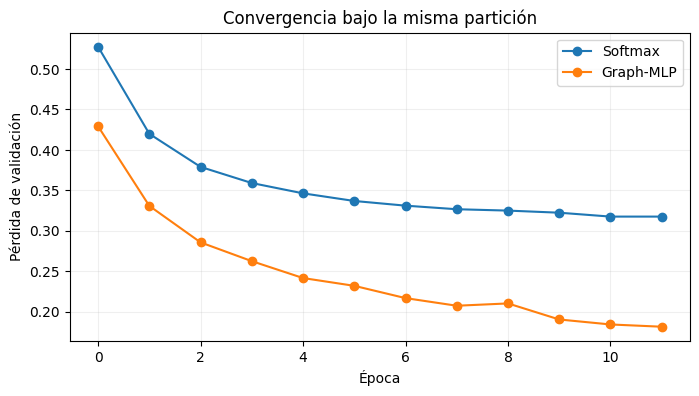

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(hist_softmax.val_loss, marker="o", label="Softmax")
plt.plot(hist_graph.val_loss, marker="o", label="Graph-MLP")
plt.xlabel("Época"); plt.ylabel("Pérdida de validación"); plt.legend(); plt.grid(alpha=.2)
plt.title("Convergencia bajo la misma partición")
plt.show()

## Resultado esperado

Softmax: exactitud ≈ 0.923 y F1 macro ≈ 0.922. Graph-MLP: exactitud ≈ 0.956 y F1 macro ≈ 0.955. Pequeñas variaciones pueden aparecer por la implementación BLAS, pero la semilla y las particiones permanecen fijas.

In [10]:
from pathlib import Path
import sys, urllib.request
import numpy as np

SEED = 2026
rng = np.random.default_rng(SEED)

# Funciona desde notebooks/ en el repositorio y también en Colab.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw" / "mnist.npz"
SRC = ROOT / "src"
if not SRC.exists():
    # Si se subió solo el notebook, crea una ruta local y descarga los datos.
    ROOT = Path.cwd()
    DATA = ROOT / "mnist.npz"
if not DATA.exists():
    DATA.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz", DATA
    )
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

data = np.load(DATA)
x_train = data["x_train"].astype(np.float32) / 255.0
y_train = data["y_train"].astype(np.int64)
x_test = data["x_test"].astype(np.float32) / 255.0
y_test = data["y_test"].astype(np.int64)
print("Semilla:", SEED, "| entrenamiento:", x_train.shape, "| prueba:", x_test.shape)

Semilla: 2026 | entrenamiento: (60000, 28, 28) | prueba: (10000, 28, 28)


In [11]:
from modelado_mnist import *
raw = raw_features(x_train)
graph = graph_message_features(x_train, alpha=0.35, steps=2)
idx = stratified_indices(y_train, 12000, seed=SEED)
y = y_train[idx]
rows = []
for fold, (tr, va) in enumerate(stratified_folds(y, 3, SEED), 1):
    for name, feats in (("Softmax", raw[idx]), ("Graph-MLP", graph[idx])):
        model = SoftmaxRegression(784, seed=SEED+fold) if name == "Softmax" else GraphMLP(784, seed=SEED+fold)
        model.fit(feats[tr], y[tr], feats[va], y[va], epochs=7, seed=SEED+fold)
        m = classification_metrics(y[va], model.predict_proba(feats[va]))
        rows.append((fold, name, m["accuracy"], m["f1_macro"], m["log_loss"]))
rows

[(1, 'Softmax', 0.888, 0.8876950619966613, 0.40487486124038696),
 (1, 'Graph-MLP', 0.91, 0.9097825411988684, 0.308861643075943),
 (2, 'Softmax', 0.892, 0.8913062759549714, 0.402599573135376),
 (2, 'Graph-MLP', 0.91275, 0.9123133538781696, 0.311621755361557),
 (3, 'Softmax', 0.89175, 0.8916043275051269, 0.41084104776382446),
 (3, 'Graph-MLP', 0.91775, 0.9174911729544302, 0.3035197854042053)]

In [12]:
for name in ("Softmax", "Graph-MLP"):
    r = np.array([[a, f, l] for _, n, a, f, l in rows if n == name])
    print(name, "media [accuracy, F1, log-loss] =", r.mean(axis=0).round(4), "DE =", r.std(axis=0, ddof=1).round(4))

Softmax media [accuracy, F1, log-loss] = [0.8906 0.8902 0.4061] DE = [0.0022 0.0022 0.0043]
Graph-MLP media [accuracy, F1, log-loss] = [0.9135 0.9132 0.308 ] DE = [0.0039 0.0039 0.0041]


## Sensibilidad reproducida desde el experimento completo

In [13]:
import json
results_path = ROOT / "data" / "processed" / "resultados.json"
if results_path.exists():
    results = json.loads(results_path.read_text(encoding="utf-8"))
    for row in results["sensitivity"]:
        print(f"{row['assumption']:24s} {str(row['value']):>8s} | F1={row['f1_macro']:.4f}")
else:
    print("Ejecute src/ejecutar_experimentos.py para regenerar la tabla completa.")

Regularizacion L2             0.0 | F1=0.9251
Regularizacion L2          0.0001 | F1=0.9251
Regularizacion L2           0.001 | F1=0.9237
Pasos de propagacion            0 | F1=0.9273
Pasos de propagacion            1 | F1=0.9256
Pasos de propagacion            2 | F1=0.9251
Pasos de propagacion            3 | F1=0.9221
Tamano de entrenamiento      5000 | F1=0.8882
Tamano de entrenamiento     10000 | F1=0.9216
Tamano de entrenamiento     15000 | F1=0.9259


## Interpretación

El resultado es estable ante L2 entre 0 y 10⁻⁴. Tres pasos reducen el F1 por sobre-suavizado: los nodos vecinos se vuelven demasiado parecidos. La conclusión es más sensible al tamaño de entrenamiento; con 5,000 ejemplos el F1 cae cerca de cuatro puntos. La ablation con cero pasos también revela que la no linealidad explica una parte mayor de la mejora que la propagación fija, por lo que no se atribuye toda la ganancia al grafo.